# Retrieval AUgmented Generation PT.1

In [16]:
import getpass
import os
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_openai import OpenAIEmbeddings
from langchain.chat_models import init_chat_model

os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_API_KEY"] = getpass.getpass()


if not os.environ.get("OPENAI_API_KEY"):
  os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter API key for OpenAI: ")

embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

llm = init_chat_model("gpt-4o-mini", model_provider="openai")
vector_store = InMemoryVectorStore(embeddings)

## Indexing 
Using WebBasedLoader to load HTML from URLS and Beautiful Soup to Parse it into text

In [17]:
# Use Document loader to parse the urllib into text
import bs4
from langchain_community.document_loaders import WebBaseLoader

# Only keep post title, headers, and content from the full HTML.
bs4_strainer = bs4.SoupStrainer(class_=("post-title", "post-header", "post-content"))
loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
    #bs_kwargs is used to customise paramaters 
    bs_kwargs={"parse_only": bs4_strainer}
)
docs = loader.load()

assert len(docs) == 1
print(f"Total characters: {len(docs[0].page_content)}")



Total characters: 43047


In [18]:
print(docs[0].page_content[:500])



      LLM Powered Autonomous Agents
    
Date: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng


Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.
Agent System Overview#
In


## Splitting the document
Seems as though the loaded document has 42k characters which is far to large to fit into the context window of many models, we need to split the document into chunks for embedding and vector storage.
This aims to help the model retrieve only the most important parts of the blog post at run time.
we use a RecursiveCharacterTextSplitter, which will recursively split the document using common separators like new lines until each chunk is the appropriate size. This is the recommended text splitter for generic text use cases.

In [19]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,  # chunk size (characters)
    chunk_overlap=200,  # chunk overlap (characters)
    add_start_index=True,  # track index in original document
)
all_splits = text_splitter.split_documents(docs)

print(f"Split blog post into {len(all_splits)} sub-documents.")

Split blog post into 63 sub-documents.


## Storing the Document
Now we need to store all chunks so we can search over them at run time.
To do this we will store them into a vectore

In [20]:
document_ids = vector_store.add_documents(documents=all_splits)

print(document_ids[:3])

['f27a6062-a920-4ceb-b8f7-73c4b5ee794b', '131c7ad0-ddd3-41eb-aa41-c2872004d9b6', 'ae38192d-429f-4934-b5f2-ab5e688b4b2f']


## 2. Retrieval and Generation

Creating the actual application logic that takes the users question, searches for relevant documents, passews the retrieved documents and initial questions into a model and generates and answer

In [21]:
from langchain import hub

#Using a prompt from the langchain hub:
### Prompt:
# # You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question.
#  If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.


prompt = hub.pull("rlm/rag-prompt")

example_messages = prompt.invoke(
    {"context" : "(context goes here)", "question" : "(question goes here)"}
).to_messages()

assert len(example_messages) == 1
print(example_messages[0].content)

C:\Users\sethh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\langsmith\client.py:290: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
Question: (question goes here) 
Context: (context goes here) 
Answer:


We'll use LangGraph to tie together the retrieval and generation steps into a single application. This will bring a number of benefits

State:
The state of our application controls what data is input to the application, transferred between steps, and output by the application. It is typically a TypedDict, but can also be a Pydantic BaseModel.

For a simple RAG application, we can just keep track of the input question, retrieved context, and generated answer:

In [22]:
from langchain_core.documents import Document
from typing_extensions import List, TypedDict


class State(TypedDict):
    question: str
    context: List[Document]
    answer: str

In [23]:
# Retrives the documents similar to the question saved in state
def retrieve(state: State):
    retrieved_docs = vector_store.similarity_search(state["question"])
    return {"context": retrieved_docs}

# Generates an answer using the llm with the given question and relevant documents
def generate(state: State):
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    messages = prompt.invoke({"question": state["question"], "context": docs_content})
    response = llm.invoke(messages)
    return {"answer": response.content}

### Control Flow
Compiling the application into a single graph object. FOr this one we are just connecting the retrival and generation steps into a single sequence.

In [24]:
from langgraph.graph import START, StateGraph

graph_builder = StateGraph(State).add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()

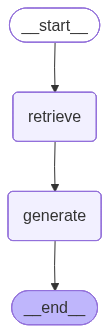

In [25]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png())) 

In [26]:
result = graph.invoke({"question": "What is Task Decomposition?"})

print(f"Context: {result['context']}\n\n")
print(f"Answer: {result['answer']}")

Context: [Document(id='d8964378-c4d8-43ae-8ebf-80df4c16f6d2', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'start_index': 2578}, page_content='Task decomposition can be done (1) by LLM with simple prompting like "Steps for XYZ.\\n1.", "What are the subgoals for achieving XYZ?", (2) by using task-specific instructions; e.g. "Write a story outline." for writing a novel, or (3) with human inputs.\nAnother quite distinct approach, LLM+P (Liu et al. 2023), involves relying on an external classical planner to do long-horizon planning. This approach utilizes the Planning Domain Definition Language (PDDL) as an intermediate interface to describe the planning problem. In this process, LLM (1) translates the problem into “Problem PDDL”, then (2) requests a classical planner to generate a PDDL plan based on an existing “Domain PDDL”, and finally (3) translates the PDDL plan back into natural language. Essentially, the planning step is outsourced to an external tool,